In [1]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (16,12)

In [2]:
 !wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2026-07-03 17:12:35--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 192.178.219.113, 192.178.219.139, 192.178.219.138, ...
Connecting to drive.google.com (drive.google.com)|192.178.219.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2026-07-03 17:12:36--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.216.132, 2607:f8b0:400c:c12::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.216.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.

In [3]:
df = pd.read_csv('./E-commerce.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2500 non-null   int64  
 1   n_clicks                 2500 non-null   int64  
 2   n_visits                 2500 non-null   int64  
 3   amount_spent             2500 non-null   float64
 4   amount_discount          2500 non-null   float64
 5   days_since_registration  2500 non-null   int64  
 6   profile_information      2500 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 136.8 KB


In [4]:
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [5]:
df.drop('ID',axis=1,inplace=True)

In [6]:
std_scaler = StandardScaler().fit(df)
std_df = std_scaler.transform(df)

In [7]:
std_df = pd.DataFrame(std_df,columns=df.columns)

std_df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,-1.495250,-0.758535,-1.054611,-0.732800,0.323118,0.339192
1,0.720691,-1.247488,-0.690292,-0.786002,0.272672,-0.310034
2,0.597285,0.193635,-0.246428,0.935872,0.464365,2.077120
3,1.573801,-0.295317,-0.213449,0.947616,-0.534456,-0.010392
4,-1.006992,-0.269583,-1.083008,-0.665697,0.424009,0.578906


In [8]:
from sklearn.decomposition import PCA


In [9]:
pca = PCA(2)


components = pca.fit_transform(std_df)

components

array([[-1.37865644, -0.60629433],
       [-0.45333573, -0.9157782 ],
       [ 0.91208762,  1.58755365],
       ...,
       [-0.14401061,  0.13306865],
       [-2.07682451,  0.40814909],
       [ 2.45974299,  0.27987605]])

In [10]:
x_1 = components[:,0]
x_2 = components[:,1]

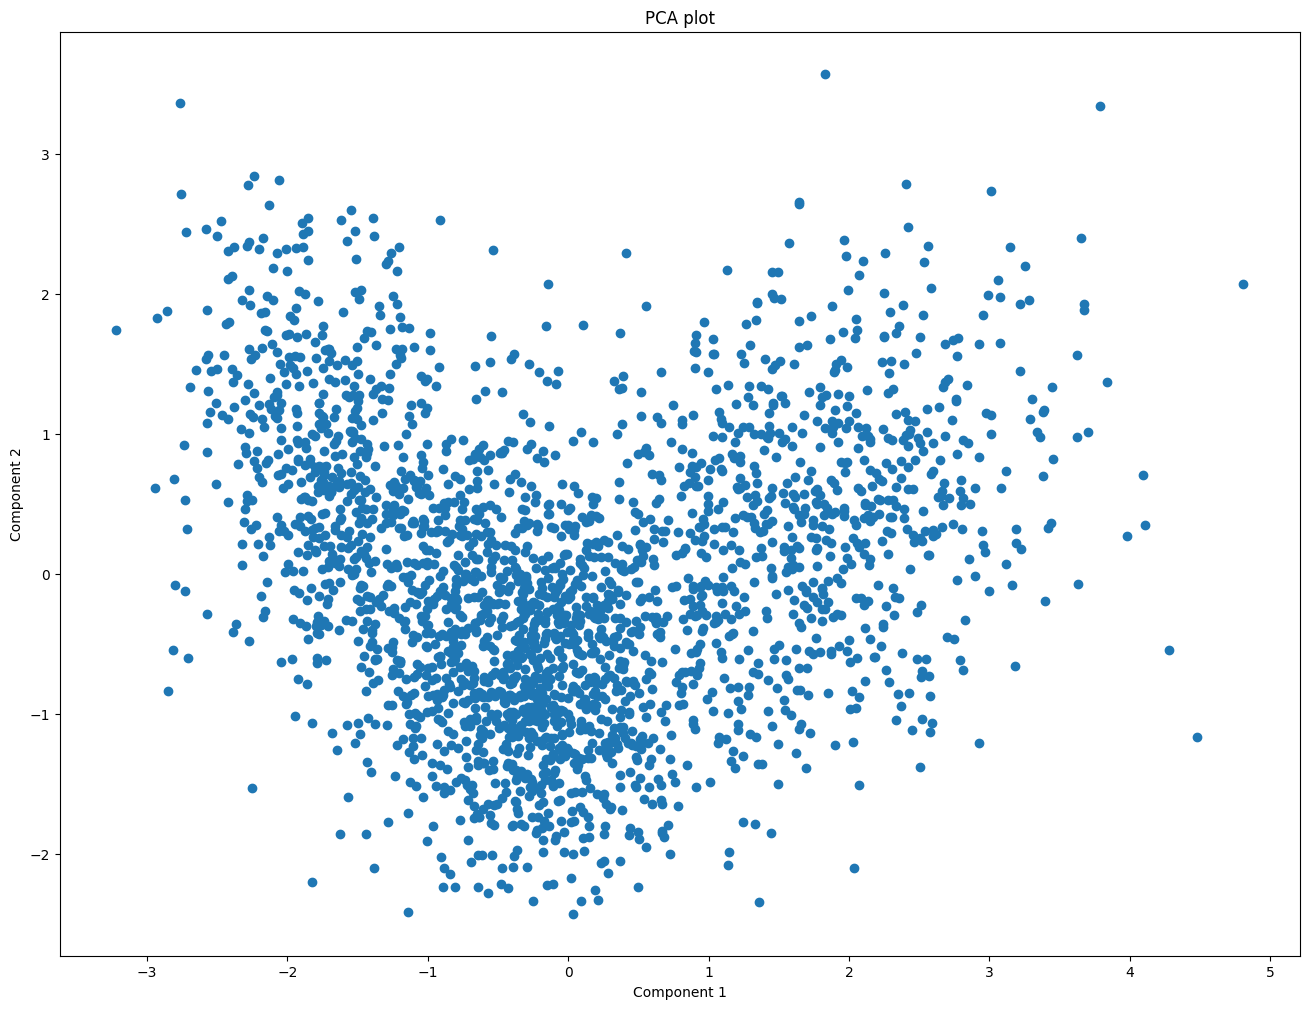

In [11]:
plt.scatter(x_1,x_2)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PCA plot")
plt.show()

In [14]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3).fit(std_df)

In [16]:
std_df

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,-1.495250,-0.758535,-1.054611,-0.732800,0.323118,0.339192
1,0.720691,-1.247488,-0.690292,-0.786002,0.272672,-0.310034
2,0.597285,0.193635,-0.246428,0.935872,0.464365,2.077120
3,1.573801,-0.295317,-0.213449,0.947616,-0.534456,-0.010392
4,-1.006992,-0.269583,-1.083008,-0.665697,0.424009,0.578906
...,...,...,...,...,...,...
2495,2.121079,0.656854,-0.807284,-0.030993,1.634702,-0.939285
2496,0.393397,-0.887207,-0.783838,-0.545880,-0.897664,1.527775
2497,-0.180709,0.425245,-1.237839,-0.797683,-1.180159,2.526585
2498,-0.738719,-1.607768,1.495086,-0.637261,-0.907753,0.139430


In [18]:
probs = gmm.predict_proba(std_df)

In [19]:
probs

array([[1.97153636e-003, 1.80716772e-001, 8.17311692e-001],
       [8.00452677e-010, 1.47483162e-002, 9.85251683e-001],
       [1.00000000e+000, 1.03056605e-071, 8.15028102e-015],
       ...,
       [6.31771000e-002, 4.90155882e-002, 8.87807312e-001],
       [1.07679050e-211, 1.00000000e+000, 7.96809654e-033],
       [1.00000000e+000, 1.10440073e-119, 5.82800702e-027]])

In [20]:
gmm.weights_

array([0.30992072, 0.28008929, 0.40998999])

In [15]:
labels = gmm.predict(std_df)

labels

array([2, 2, 0, ..., 2, 1, 0])

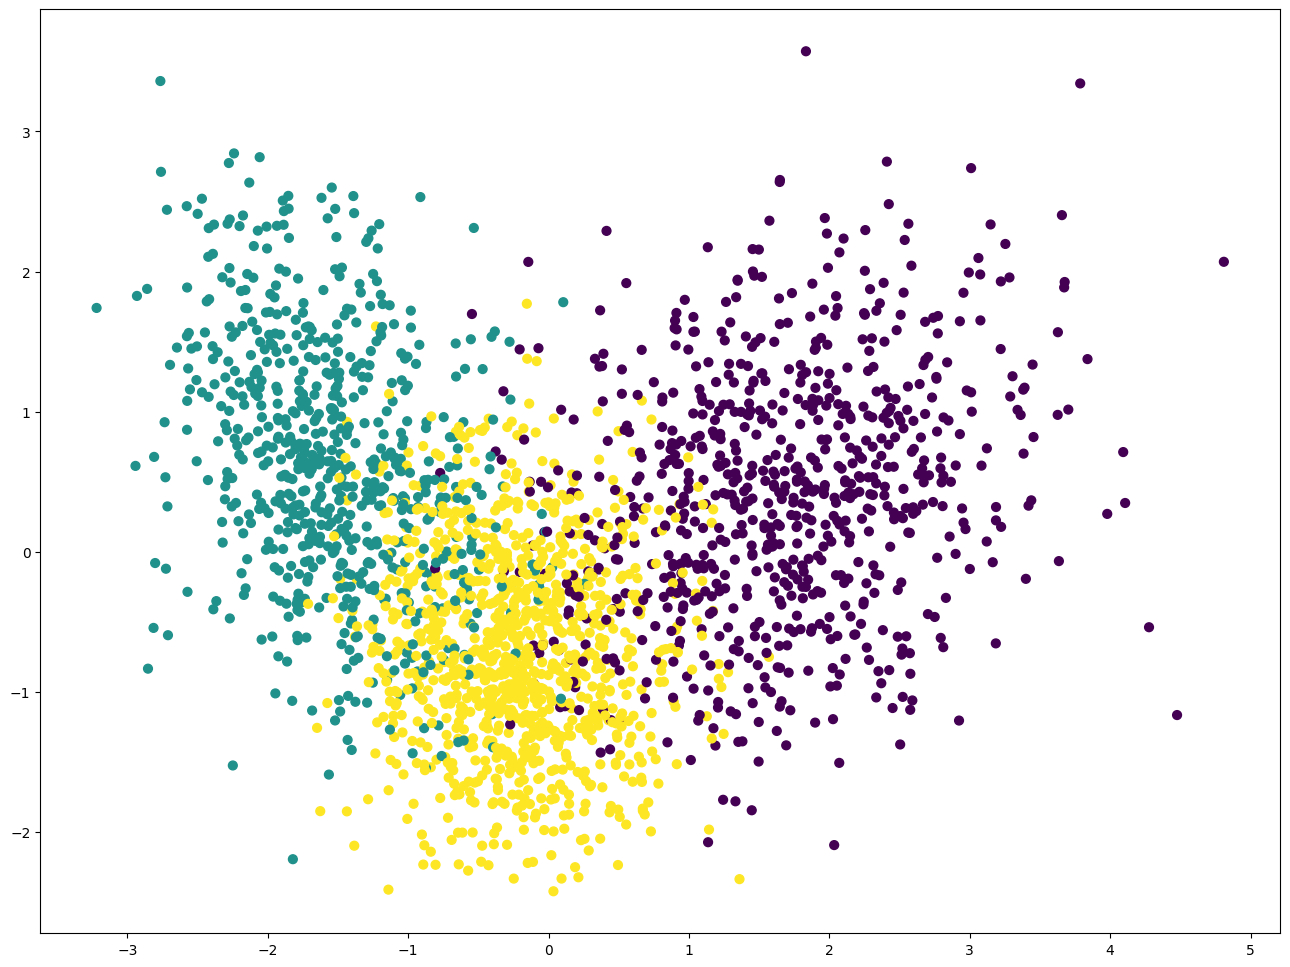

In [17]:
plt.scatter(x_1, x_2, c=labels, s=40, cmap='viridis');

In [22]:
len(gmm.means_)

3

In [23]:
gmm.means_[0]

array([ 0.87029715,  0.71598455, -0.14032637,  1.30417698,  0.01534597,
       -0.01442248])

In [25]:
gmm.covariances_[0]

array([[ 1.03274344,  0.01974918,  0.00448293, -0.00698462, -0.02792032,
        -0.02864921],
       [ 0.01974918,  1.07318659,  0.02292521,  0.04319045, -0.01638808,
         0.06631111],
       [ 0.00448293,  0.02292521,  0.18383302,  0.34979104,  0.00334383,
        -0.01695802],
       [-0.00698462,  0.04319045,  0.34979104,  0.69300377,  0.00891322,
        -0.02863236],
       [-0.02792032, -0.01638808,  0.00334383,  0.00891322,  1.01220132,
         0.03258909],
       [-0.02864921,  0.06631111, -0.01695802, -0.02863236,  0.03258909,
         1.03756373]])

## TSNE

In [27]:
std_df

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,-1.495250,-0.758535,-1.054611,-0.732800,0.323118,0.339192
1,0.720691,-1.247488,-0.690292,-0.786002,0.272672,-0.310034
2,0.597285,0.193635,-0.246428,0.935872,0.464365,2.077120
3,1.573801,-0.295317,-0.213449,0.947616,-0.534456,-0.010392
4,-1.006992,-0.269583,-1.083008,-0.665697,0.424009,0.578906
...,...,...,...,...,...,...
2495,2.121079,0.656854,-0.807284,-0.030993,1.634702,-0.939285
2496,0.393397,-0.887207,-0.783838,-0.545880,-0.897664,1.527775
2497,-0.180709,0.425245,-1.237839,-0.797683,-1.180159,2.526585
2498,-0.738719,-1.607768,1.495086,-0.637261,-0.907753,0.139430


In [29]:
from sklearn.manifold import TSNE
tsne = TSNE()
transformed_df = tsne.fit_transform(std_df)


In [31]:
tsne_x_1 = transformed_df[:,0]
tsne_x_2 = transformed_df[:,1]

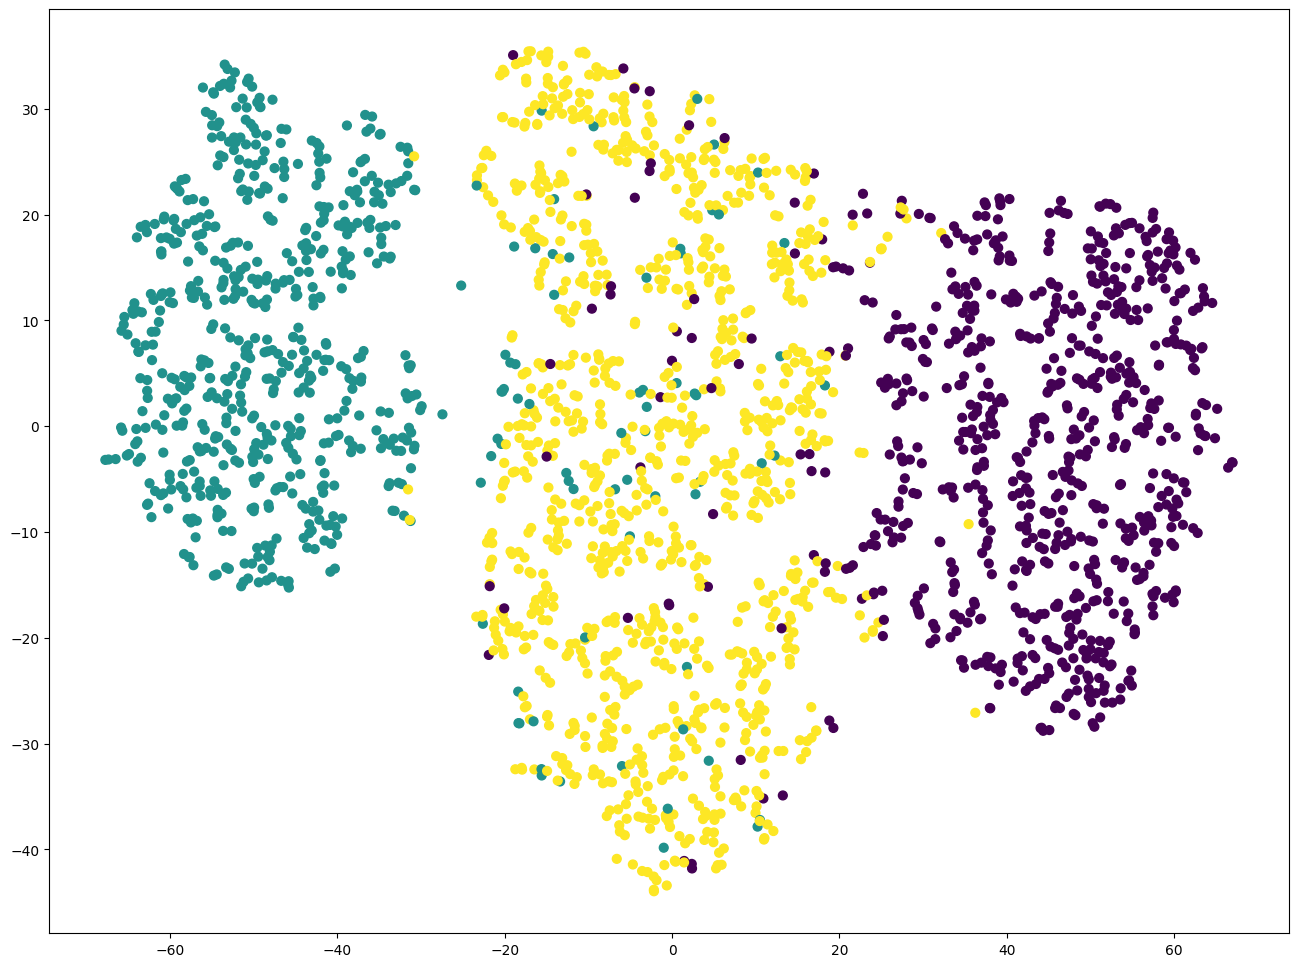

In [34]:
plt.scatter(tsne_x_1, tsne_x_2, s=40, cmap='viridis', c = labels);


In [35]:
from sklearn.cluster import KMeans


In [36]:
k = 3
kmeans = KMeans(n_clusters=k)

y_pred = kmeans.fit_predict(std_df)


In [37]:
y_pred

array([2, 2, 0, ..., 2, 1, 0], dtype=int32)

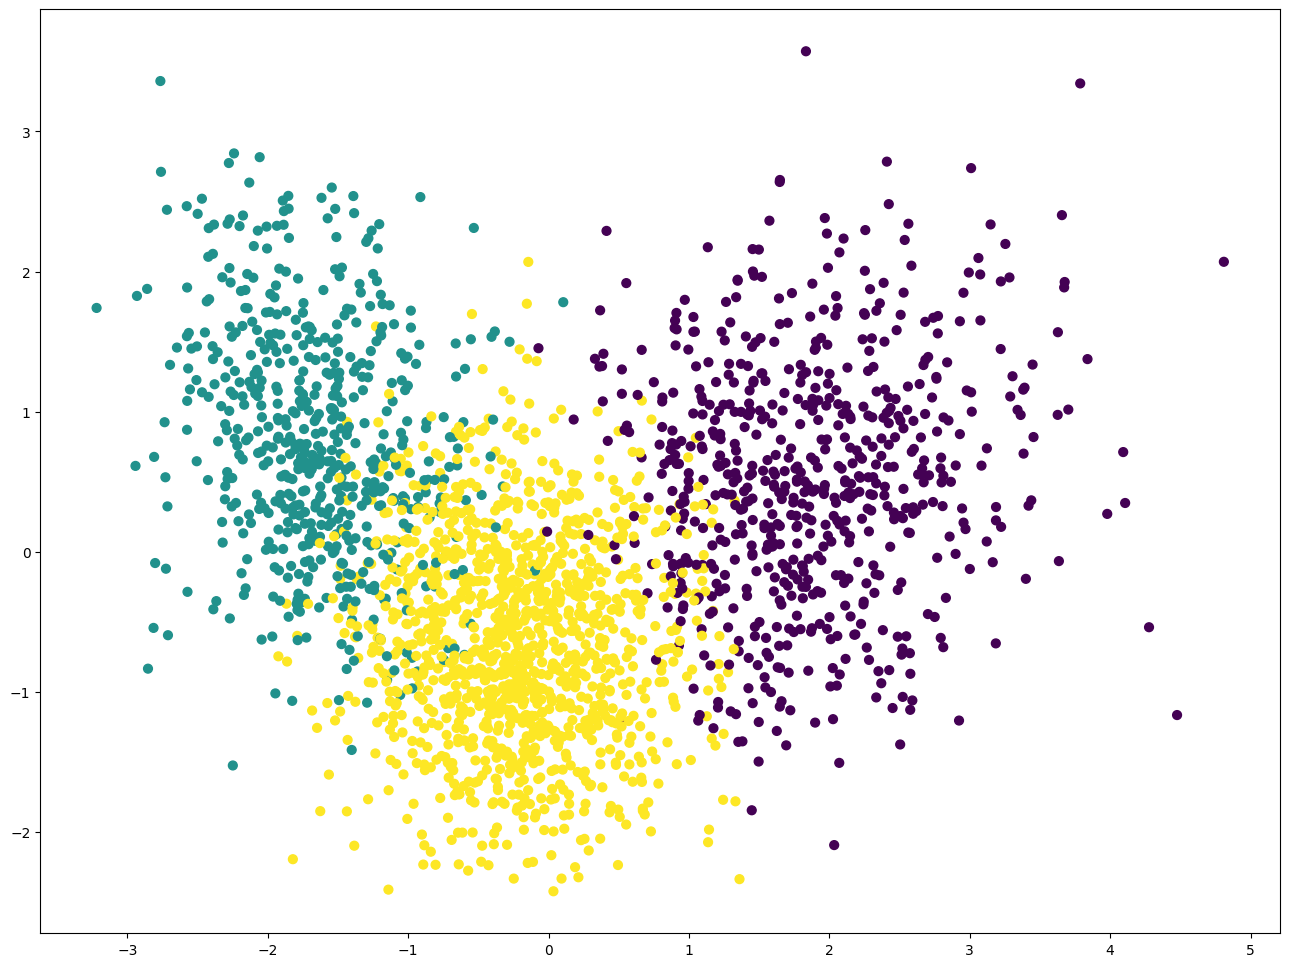

In [38]:
plt.scatter(x_1, x_2, c=kmeans.labels_, s=40, cmap='viridis');


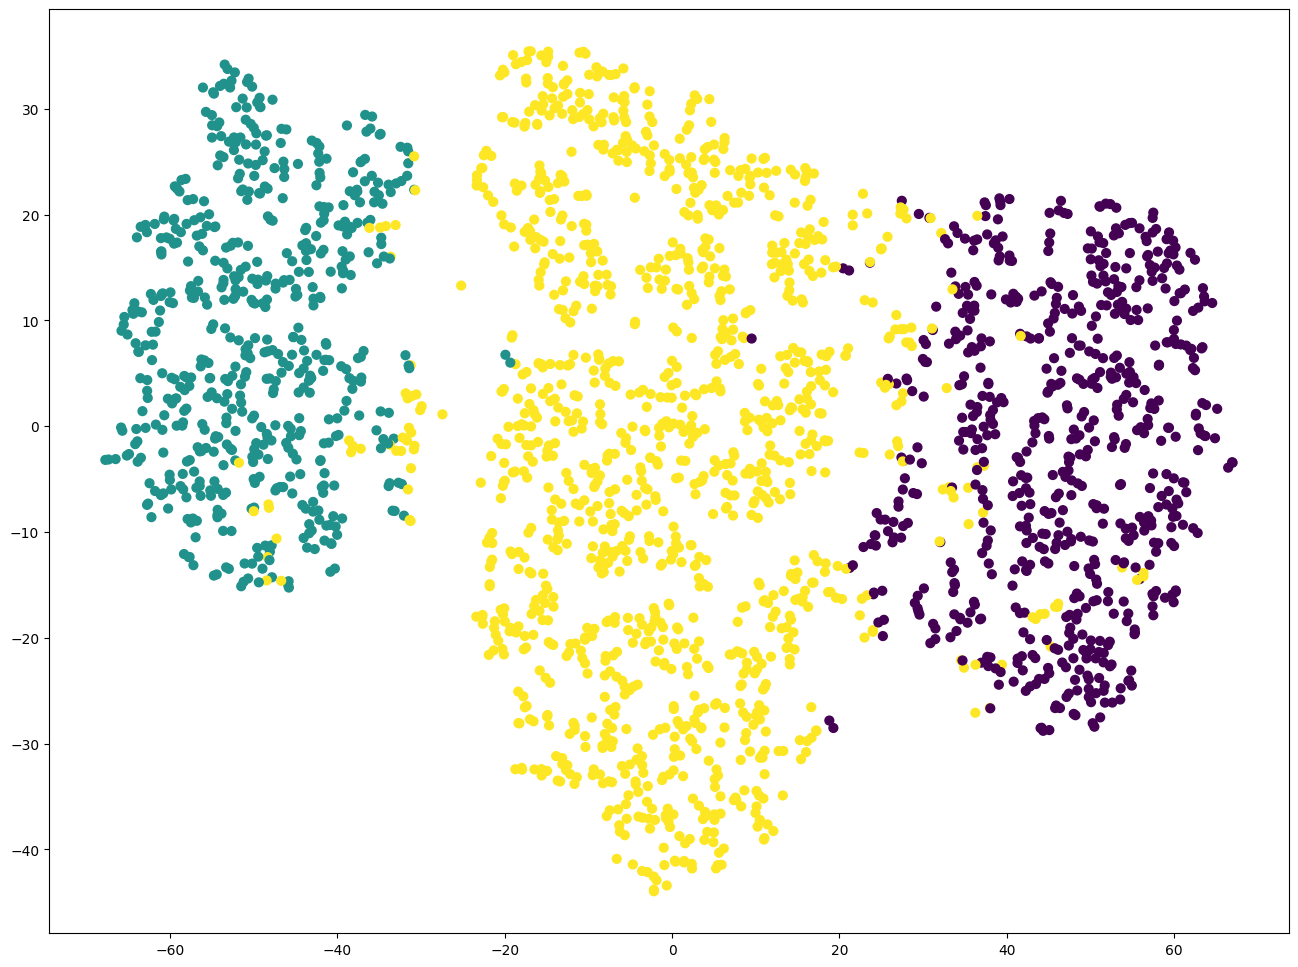

In [40]:
plt.scatter(tsne_x_1, tsne_x_2, c=kmeans.labels_, s=40, cmap='viridis');


## Some fake data

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# Set random seed for reproducibility
np.random.seed(21)

# Generate synthetic data
n_samples = 1500

# Define parameters for three Gaussian clusters
mean1 = [-2, 2]
cov1 = [[1, 0.9], [0.9, 1]]  # High correlation
mean2 = [5, 5]
cov2 = [[1, 0], [0, 1]]  # No correlation
mean3 = [-5, 5]
cov3 = [[1, -0.8], [-0.8, 1]]  # Negative correlation

In [42]:
# Generate points for each cluster
X1 = np.random.multivariate_normal(mean1, cov1, n_samples // 3)
X2 = np.random.multivariate_normal(mean2, cov2, n_samples // 3)
X3 = np.random.multivariate_normal(mean3, cov3, n_samples // 3)

In [43]:
# Combine the points to create the dataset
X = np.vstack((X1, X2, X3))

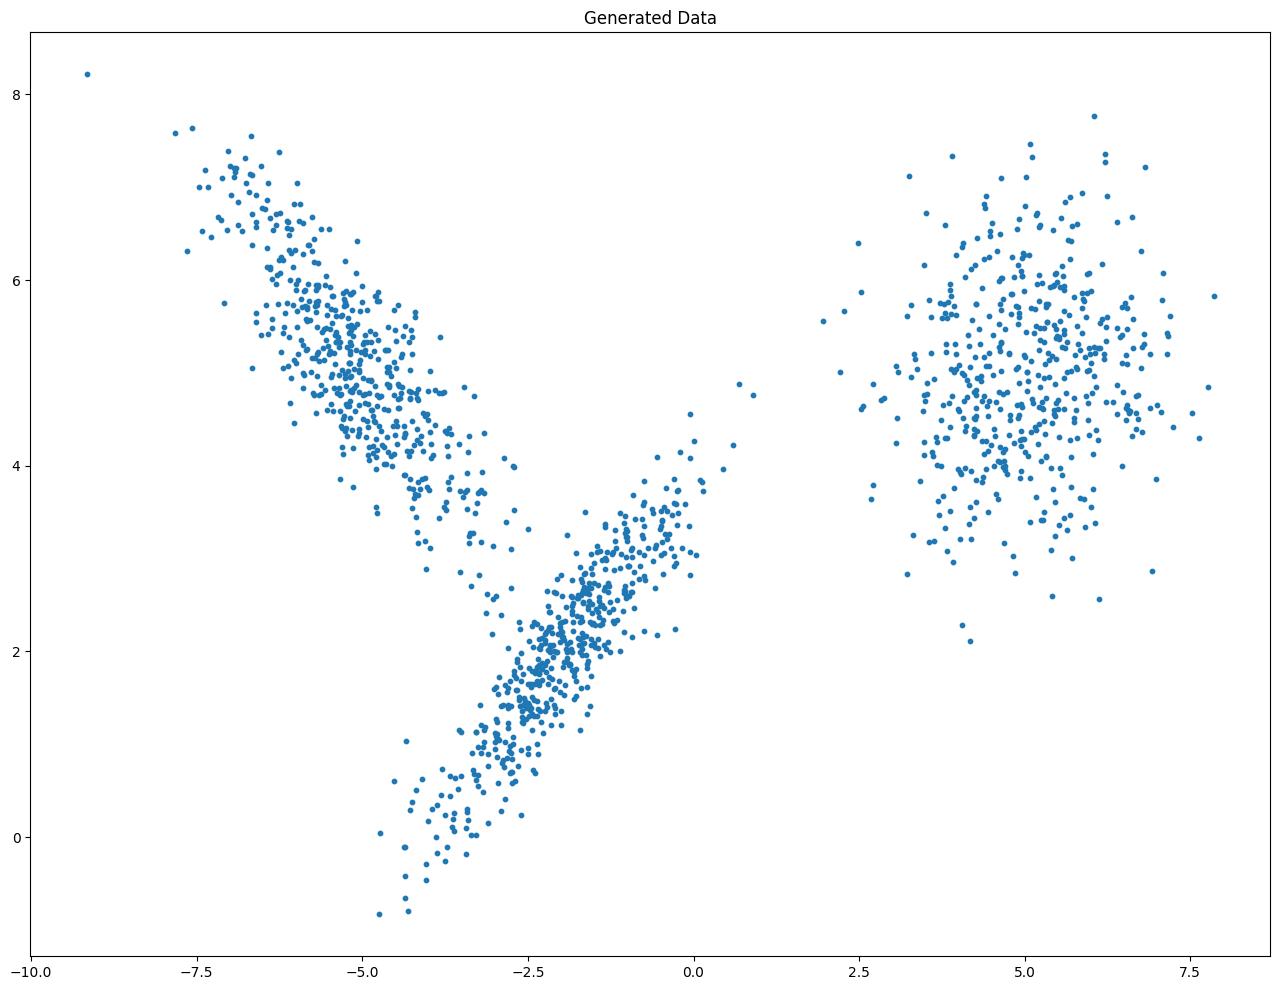

In [44]:
# Plot the generated data
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Generated Data")
plt.show()

In [45]:
# Fit a GMM model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

In [46]:
# Fit a K-means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

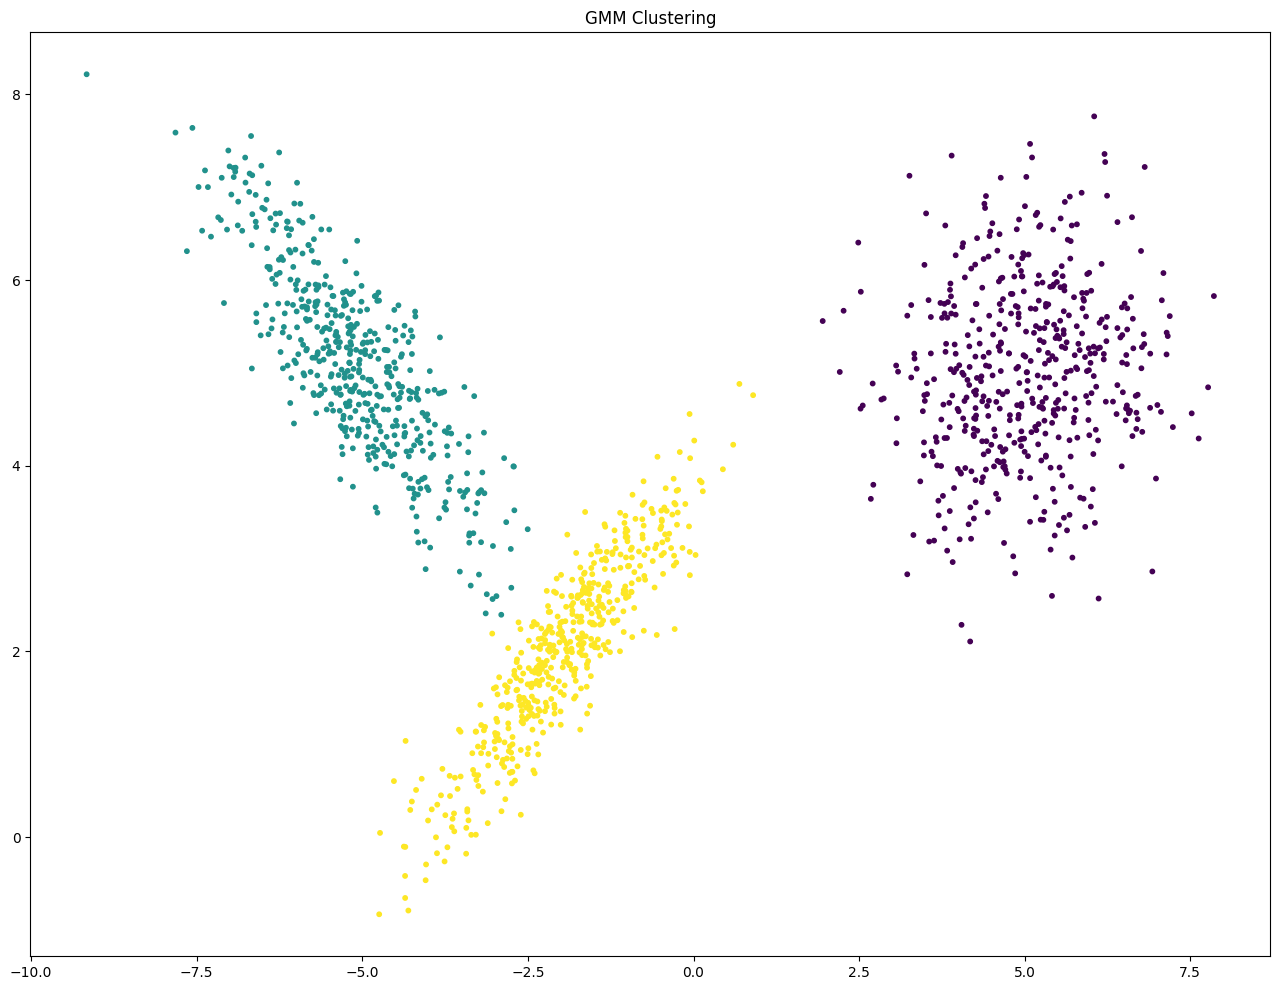

In [47]:
# Plot GMM clustering results
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=10, cmap='viridis')
plt.title("GMM Clustering")
plt.show()

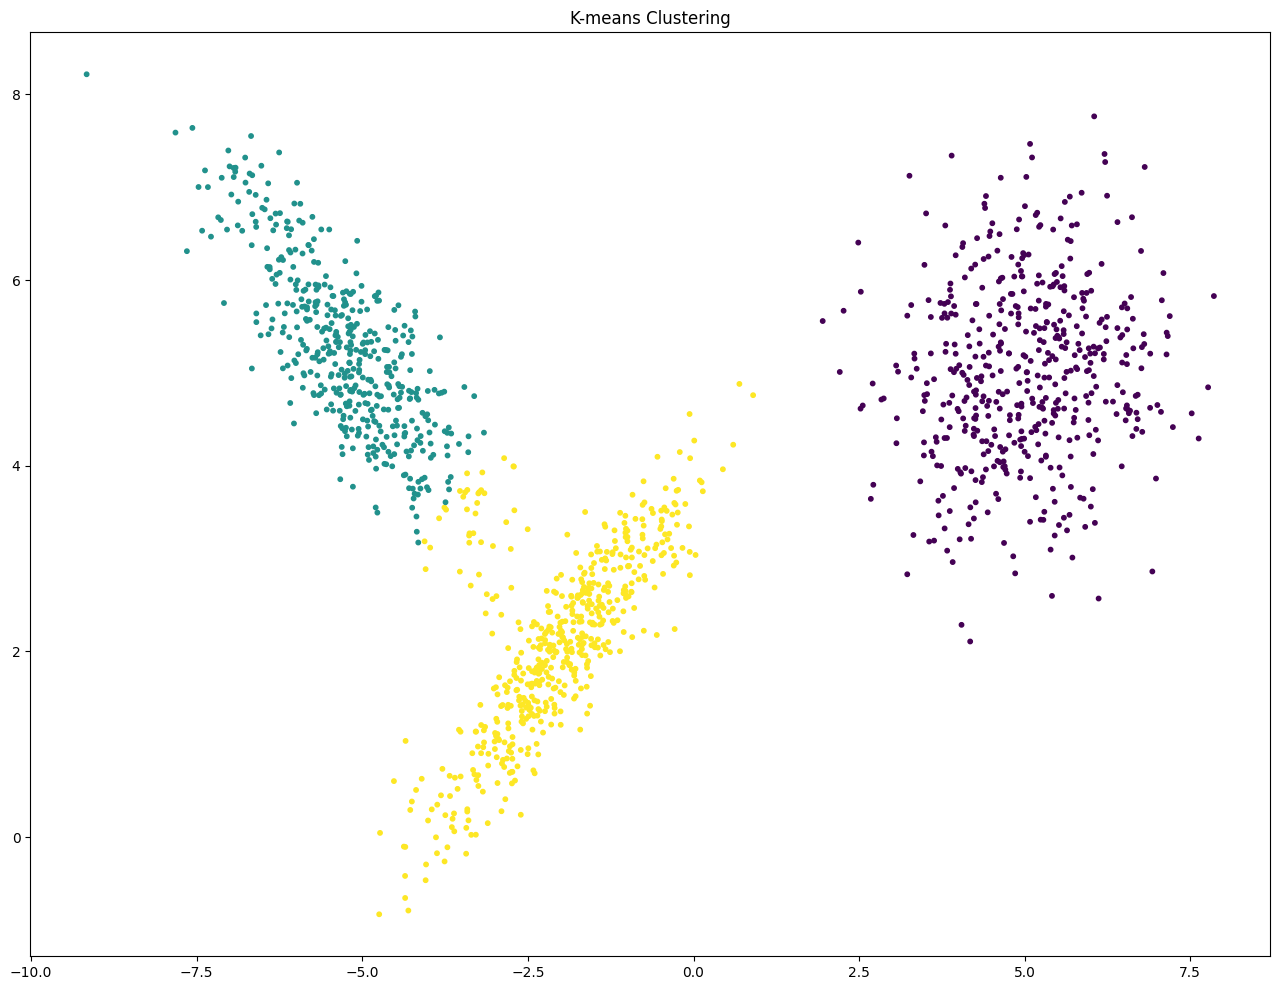

In [48]:
# Plot K-means clustering results
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10, cmap='viridis')
plt.title("K-means Clustering")
plt.show()